# data cleaning

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

In [3]:
train = pd.read_csv('train_(2)_(1)_(1)_(1).csv')
test = pd.read_csv('test_(2)_(1)_(1)_(1).csv')
avgRent = pd.read_csv('avg_rent_(1)_(1)_(1)_(1).csv')
disCityCenter = pd.read_csv('dist_from_city_centre_(1)_(1)_(1)_(1).csv')
sampleSubmission = pd.read_csv('sample_submission_(3)_(1)_(1)_(1).csv')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10656 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10656 non-null  int64  
 1   area_type     10656 non-null  object 
 2   availability  10656 non-null  object 
 3   location      10655 non-null  object 
 4   size          10642 non-null  object 
 5   society       6228 non-null   object 
 6   total_sqft    10656 non-null  object 
 7   bath          10591 non-null  float64
 8   balcony       10152 non-null  float64
 9   price         10656 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 832.6+ KB


In [5]:
train.dropna(subset=['size', 'location', 'bath', 'balcony'], inplace=True)
train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10151 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10151 non-null  int64  
 1   area_type     10151 non-null  object 
 2   availability  10151 non-null  object 
 3   location      10151 non-null  object 
 4   size          10151 non-null  object 
 5   society       5959 non-null   object 
 6   total_sqft    10151 non-null  object 
 7   bath          10151 non-null  float64
 8   balcony       10151 non-null  float64
 9   price         10151 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 872.4+ KB


### cleaning total_sqft and making it numeric 
as it is expected to be in sq feet

then scaling it

In [6]:
def is_number(x):
    try:
        float(x)
        return True
    except ValueError:
        return False

def return_sqft(x):
    if is_number(x):
        return float(x)
    
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    if x.endswith('Sq. Meter') or x.endswith('Sq. Meter'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Acres'):
        x = float(x.split('Acr')[0])
        return x*43560
    if x.endswith('Sq. Yards'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Grounds'):
        x = float(x.split('Gro')[0])
        return x*2400
    if x.endswith('Cents'):
        x = float(x.split('Cen')[0])
        return x*435.6
    if x.endswith('Perch'):
        x = float(x.split('Per')[0])
        return x*272.25
    if x.endswith('Guntha'):
        x = float(x.split('Gun')[0])
        return x*1089
    
    print("Couldn't parse the value: ", x)
    return x



train['total_sqft'] = train.total_sqft.apply(lambda x: return_sqft(x))
train[train.total_sqft.apply(lambda x: is_number(x) == False)]

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price


In [7]:
train.total_sqft.describe()

count    1.015100e+04
mean     1.831455e+03
std      1.613990e+04
min      5.000000e+00
25%      1.095000e+03
50%      1.259000e+03
75%      1.639000e+03
max      1.306800e+06
Name: total_sqft, dtype: float64

outlier treatment for total_sqft based on area_type

In [8]:
train.area_type.value_counts()

area_type
Super built-up  Area    6745
Built-up  Area          1845
Plot  Area              1496
Carpet  Area              65
Name: count, dtype: int64

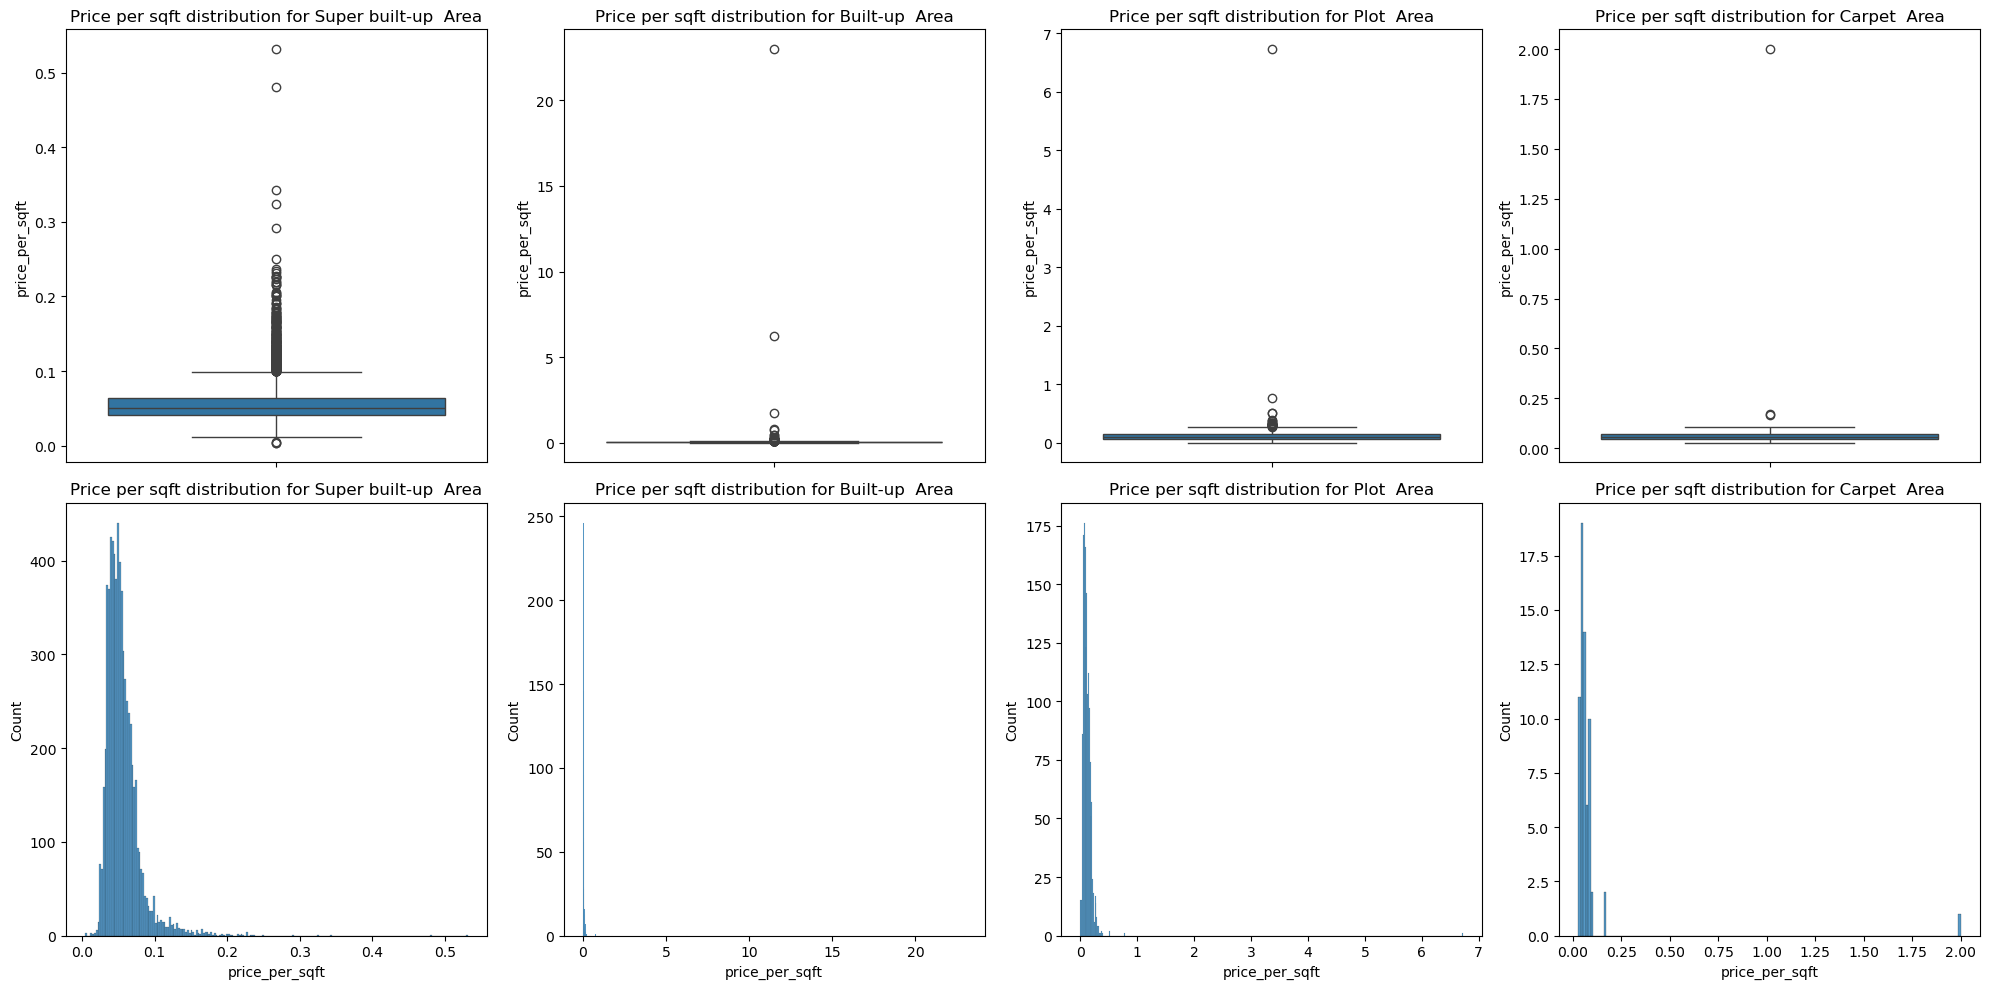

In [9]:
# TODO: outlier analysis to be done wrt area type 

# plt.subplots = plt.subplots(figsize=(10,5))

plt.figure(figsize=(20,10))
train['price_per_sqft'] = train.price / train.total_sqft


plt.subplot(2,4,1)
plt.title('Price per sqft distribution for Super built-up  Area')
sns.boxplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)
plt.subplot(2,4,5)
plt.title('Price per sqft distribution for Super built-up  Area')
sns.histplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)



plt.subplot(2,4,2)
plt.title('Price per sqft distribution for Built-up  Area')
sns.boxplot(train[train.area_type == 'Built-up  Area'].price_per_sqft)
plt.subplot(2,4,6)
plt.title('Price per sqft distribution for Built-up  Area')
sns.histplot(train[train.area_type == 'Built-up  Area'].price_per_sqft)



plt.subplot(2,4,3)
plt.title('Price per sqft distribution for Plot  Area')
sns.boxplot(train[train.area_type == 'Plot  Area'].price_per_sqft)
plt.subplot(2,4,7)
plt.title('Price per sqft distribution for Plot  Area')
sns.histplot(train[train.area_type == 'Plot  Area'].price_per_sqft)



plt.subplot(2,4,4)
plt.title('Price per sqft distribution for Carpet  Area')
sns.boxplot(train[train.area_type == 'Carpet  Area'].price_per_sqft)
plt.subplot(2,4,8)
plt.title('Price per sqft distribution for Carpet  Area')
sns.histplot(train[train.area_type == 'Carpet  Area'].price_per_sqft)



plt.tight_layout()
plt.show()

<Axes: xlabel='price_per_sqft', ylabel='Count'>

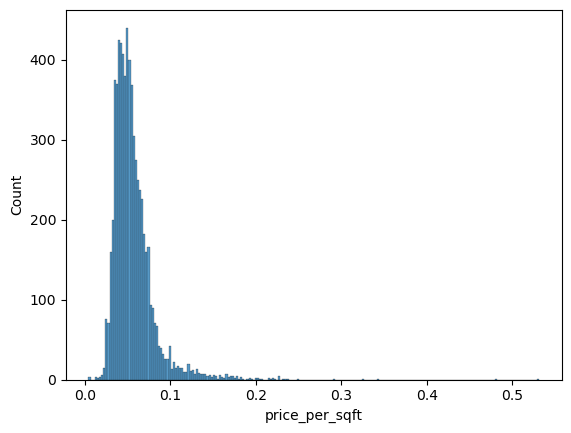

In [10]:
sns.histplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)


In [11]:
train.price_per_sqft.describe()

count    10151.000000
mean         0.069261
std          0.249677
min          0.000023
25%          0.042426
50%          0.053968
75%          0.071713
max         23.000000
Name: price_per_sqft, dtype: float64

In [12]:
train[train.price_per_sqft > .6]

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
349,349,Plot Area,18-Dec,Suragajakkanahalli,3 Bedroom,PrhyaK,11.0000,3.0,2.0,74.0,6.727273
1020,1020,Carpet Area,Ready To Move,Weavers Colony,1 BHK,NaN,15.0000,1.0,0.0,30.0,2.000000
1122,1122,Built-up Area,Ready To Move,Grihalakshmi Layout,5 Bedroom,NaN,24.0000,2.0,2.0,150.0,6.250000
4972,4972,Built-up Area,Ready To Move,Srirampuram,7 BHK,NaN,5.0000,7.0,3.0,115.0,23.000000
5668,5668,Built-up Area,Ready To Move,Judicial Layout,5 Bedroom,NaN,484.3755,6.0,3.0,400.0,0.825806
6421,6421,Plot Area,18-Sep,Bommenahalli,4 Bedroom,Prood G,2940.0000,3.0,2.0,2250.0,0.765306
7088,7088,Built-up Area,Ready To Move,Srirampuram,1 BHK,NaN,650.0000,1.0,3.0,500.0,0.769231
7657,7657,Built-up Area,Ready To Move,Raghuvanahalli,1 BHK,NaN,425.0000,1.0,1.0,750.0,1.764706


In [13]:
train.drop(train[train.price_per_sqft > 0.6].index, inplace=True, axis=0)

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10655
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10143 non-null  int64  
 1   area_type       10143 non-null  object 
 2   availability    10143 non-null  object 
 3   location        10143 non-null  object 
 4   size            10143 non-null  object 
 5   society         5957 non-null   object 
 6   total_sqft      10143 non-null  float64
 7   bath            10143 non-null  float64
 8   balcony         10143 non-null  float64
 9   price           10143 non-null  float64
 10  price_per_sqft  10143 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 950.9+ KB


In [15]:
# note that we must do outlier treatment before scaling
# min max scaling for total_sqft

train.total_sqft = train.total_sqft.apply(lambda x: (x - train.total_sqft.min())/(train.total_sqft.max() - train.total_sqft.min()))

successfully cleaned all non numeric data from total_sqft col

## handling size
- currently 1rk = 0
- 1bhk/1bedroom = 1
- 2bhk/2bedroom = 2 
and soo on

In [16]:
train['size'].value_counts(dropna=False)

size
2 BHK         4108
3 BHK         3270
4 Bedroom      596
3 Bedroom      427
1 BHK          426
4 BHK          390
2 Bedroom      280
5 Bedroom      204
6 Bedroom      137
1 Bedroom       88
7 Bedroom       54
8 Bedroom       51
5 BHK           31
9 Bedroom       26
6 BHK           16
1 RK            13
7 BHK           10
9 BHK            5
11 Bedroom       2
8 BHK            2
11 BHK           1
27 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
10 Bedroom       1
13 BHK           1
Name: count, dtype: int64

In [17]:
train[train['size'].apply(lambda x: is_number(x) == False)]


,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,0.000774,2.0,1.0,39.07,0.036998
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,0.001955,5.0,3.0,120.00,0.046154
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,0.001068,2.0,3.0,62.00,0.043056
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,0.001130,3.0,1.0,95.00,0.062459
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,0.000884,2.0,1.0,51.00,0.042500
...,...,...,...,...,...,...,...,...,...,...,...
10651,10651,Plot Area,Ready To Move,Parappana Agrahara,1 Bedroom,NaN,0.000884,1.0,0.0,45.00,0.037500
10652,10652,Super built-up Area,Ready To Move,Bhoganhalli,2 BHK,Srhemay,0.000930,2.0,1.0,69.90,0.055476
10653,10653,Super built-up Area,Ready To Move,Doddanakundi Industrial Area 2,2 BHK,NaN,0.000801,2.0,1.0,49.00,0.044872
10654,10654,Super built-up Area,Ready To Move,Kachanayakanahalli,2 BHK,ICoolon,0.000598,2.0,0.0,34.00,0.041112


In [18]:
def returnSize(x):
    try:
        if x == '1 RK':
            return 0
        else:
            return int(x.split(' ')[0])
    except:
        print("Couldn't parse size: ", x)

In [19]:
train['size'] = train['size'].apply(lambda x: returnSize(x))

In [20]:
train

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,0.000774,2.0,1.0,39.07,0.036998
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,0.001955,5.0,3.0,120.00,0.046154
2,2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,0.001068,2.0,3.0,62.00,0.043056
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,0.001130,3.0,1.0,95.00,0.062459
4,4,Super built-up Area,Ready To Move,Kothanur,2,NaN,0.000884,2.0,1.0,51.00,0.042500
...,...,...,...,...,...,...,...,...,...,...,...
10651,10651,Plot Area,Ready To Move,Parappana Agrahara,1,NaN,0.000884,1.0,0.0,45.00,0.037500
10652,10652,Super built-up Area,Ready To Move,Bhoganhalli,2,Srhemay,0.000930,2.0,1.0,69.90,0.055476
10653,10653,Super built-up Area,Ready To Move,Doddanakundi Industrial Area 2,2,NaN,0.000801,2.0,1.0,49.00,0.044872
10654,10654,Super built-up Area,Ready To Move,Kachanayakanahalli,2,ICoolon,0.000598,2.0,0.0,34.00,0.041112


In [21]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10655
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10143 non-null  int64  
 1   area_type       10143 non-null  object 
 2   availability    10143 non-null  object 
 3   location        10143 non-null  object 
 4   size            10143 non-null  int64  
 5   society         5957 non-null   object 
 6   total_sqft      10143 non-null  float64
 7   bath            10143 non-null  float64
 8   balcony         10143 non-null  float64
 9   price           10143 non-null  float64
 10  price_per_sqft  10143 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 950.9+ KB


## avilibility


In [22]:
train.availability.value_counts()

availability
Ready To Move    8050
18-Dec            223
18-May            220
18-Apr            197
18-Aug            162
                 ... 
16-Oct              1
15-Aug              1
17-Jan              1
16-Nov              1
20-Apr              1
Name: count, Length: 75, dtype: int64

In [23]:
from datetime import datetime

def noOfDays(x):
    if x == 'Ready To Move':
        return 0
    tokens = x.split('-')
    if len(tokens) == 2:
        now = datetime.now()

        date = datetime.strptime(f'{x}-{now.year}', '%d-%b-%Y')

        if (date - now).days < 0:
            date = datetime.strptime(f'{x}-{now.year + 1}', '%d-%b-%Y')
            
        return (date - now).days
    else:
        print("Couldn't parse availability: ", x)
        return -1

In [24]:
train.availability = train.availability.apply(lambda x: noOfDays(x))

In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10655
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10143 non-null  int64  
 1   area_type       10143 non-null  object 
 2   availability    10143 non-null  int64  
 3   location        10143 non-null  object 
 4   size            10143 non-null  int64  
 5   society         5957 non-null   object 
 6   total_sqft      10143 non-null  float64
 7   bath            10143 non-null  float64
 8   balcony         10143 non-null  float64
 9   price           10143 non-null  float64
 10  price_per_sqft  10143 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 950.9+ KB


In [26]:
train.area_type.value_counts()  

area_type
Super built-up  Area    6745
Built-up  Area          1840
Plot  Area              1494
Carpet  Area              64
Name: count, dtype: int64

In [27]:
train

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
0,0,Super built-up Area,343,Electronic City Phase II,2,Coomee,0.000774,2.0,1.0,39.07,0.036998
1,1,Plot Area,0,Chikka Tirupathi,4,Theanmp,0.001955,5.0,3.0,120.00,0.046154
2,2,Built-up Area,0,Uttarahalli,3,NaN,0.001068,2.0,3.0,62.00,0.043056
3,3,Super built-up Area,0,Lingadheeranahalli,3,Soiewre,0.001130,3.0,1.0,95.00,0.062459
4,4,Super built-up Area,0,Kothanur,2,NaN,0.000884,2.0,1.0,51.00,0.042500
...,...,...,...,...,...,...,...,...,...,...,...
10651,10651,Plot Area,0,Parappana Agrahara,1,NaN,0.000884,1.0,0.0,45.00,0.037500
10652,10652,Super built-up Area,0,Bhoganhalli,2,Srhemay,0.000930,2.0,1.0,69.90,0.055476
10653,10653,Super built-up Area,0,Doddanakundi Industrial Area 2,2,NaN,0.000801,2.0,1.0,49.00,0.044872
10654,10654,Super built-up Area,0,Kachanayakanahalli,2,ICoolon,0.000598,2.0,0.0,34.00,0.041112


## encoding area type

n-1 dummy encoding performed 

with value counts

- area_type
- Super built-up  Area    6745
- Built-up  Area          1845
- Plot  Area              1496
- Carpet  Area              65

model performance to be tested including only Super built-up  Area 

In [28]:
temp = True
for i in train.area_type.unique():
    if temp:
        temp = False
        continue
    train["area_type_" + i.split("  ")[0].replace(" ", "_").replace("-", "_")] = train.area_type.apply(lambda x: 1 if x==i else 0)

train.drop('area_type', axis=1, inplace=True)

In [29]:
train

,ID,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft,area_type_Plot,area_type_Built_up,area_type_Carpet
0,0,343,Electronic City Phase II,2,Coomee,0.000774,2.0,1.0,39.07,0.036998,0,0,0
1,1,0,Chikka Tirupathi,4,Theanmp,0.001955,5.0,3.0,120.00,0.046154,1,0,0
2,2,0,Uttarahalli,3,NaN,0.001068,2.0,3.0,62.00,0.043056,0,1,0
3,3,0,Lingadheeranahalli,3,Soiewre,0.001130,3.0,1.0,95.00,0.062459,0,0,0
4,4,0,Kothanur,2,NaN,0.000884,2.0,1.0,51.00,0.042500,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10651,10651,0,Parappana Agrahara,1,NaN,0.000884,1.0,0.0,45.00,0.037500,1,0,0
10652,10652,0,Bhoganhalli,2,Srhemay,0.000930,2.0,1.0,69.90,0.055476,0,0,0
10653,10653,0,Doddanakundi Industrial Area 2,2,NaN,0.000801,2.0,1.0,49.00,0.044872,0,0,0
10654,10654,0,Kachanayakanahalli,2,ICoolon,0.000598,2.0,0.0,34.00,0.041112,0,0,0


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10655
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  10143 non-null  int64  
 1   availability        10143 non-null  int64  
 2   location            10143 non-null  object 
 3   size                10143 non-null  int64  
 4   society             5957 non-null   object 
 5   total_sqft          10143 non-null  float64
 6   bath                10143 non-null  float64
 7   balcony             10143 non-null  float64
 8   price               10143 non-null  float64
 9   price_per_sqft      10143 non-null  float64
 10  area_type_Plot      10143 non-null  int64  
 11  area_type_Built_up  10143 non-null  int64  
 12  area_type_Carpet    10143 non-null  int64  
dtypes: float64(5), int64(6), object(2)
memory usage: 1.1+ MB


In [35]:
# import 'Pandas' 
import pandas as pd 

# import 'Numpy' 
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn' 
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None
 
# to display the float values upto 6 decimal places     
pd.options.display.float_format = '{:.6f}'.format

# import train-test split 
from sklearn.model_selection import train_test_split

# # import various functions from statsmodels
# import statsmodels
import statsmodels.api as sm
# import statsmodels.stats.api as sms
# from statsmodels.graphics.gofplots import qqplot

# # import 'stats'
# from scipy import stats

# # 'metrics' from sklearn is used for evaluating the model performance
# from sklearn.metrics import mean_squared_error

# # import functions to perform feature selection
# from mlxtend.feature_selection import SequentialFeatureSelector as sfs
# #from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE

# import function to perform linear regression
from sklearn.linear_model import LinearRegression

# import functions to perform cross validation
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10655
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  10143 non-null  int64  
 1   availability        10143 non-null  int64  
 2   location            10143 non-null  object 
 3   size                10143 non-null  int64  
 4   society             5957 non-null   object 
 5   total_sqft          10143 non-null  float64
 6   bath                10143 non-null  float64
 7   balcony             10143 non-null  float64
 8   price               10143 non-null  float64
 9   price_per_sqft      10143 non-null  float64
 10  area_type_Plot      10143 non-null  int64  
 11  area_type_Built_up  10143 non-null  int64  
 12  area_type_Carpet    10143 non-null  int64  
dtypes: float64(5), int64(6), object(2)
memory usage: 1.1+ MB


In [34]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            2664 non-null   int64  
 1   area_type     2664 non-null   object 
 2   availability  2664 non-null   object 
 3   location      2664 non-null   object 
 4   size          2662 non-null   object 
 5   society       1590 non-null   object 
 6   total_sqft    2664 non-null   object 
 7   bath          2656 non-null   float64
 8   balcony       2559 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 187.4+ KB


In [41]:
x = train.drop('price', axis=1)
y = train['price']

x = x.select_dtypes(include= 'number')
x = sm.add_constant(x)

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1, test_size = 0.2)

# xTest = test.drop('price', axis=1)
# yTest = test['price']

In [44]:
myModel = sm.OLS(y_train, X_train).fit()
myModel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     856.9
Date:                Fri, 09 Jan 2026   Prob (F-statistic):               0.00
Time:                        23:20:04   Log-Likelihood:                -47839.
No. Observations:                8114   AIC:                         9.570e+04
Df Residuals:                    8103   BIC:                         9.578e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -92.9253      3.619    -25.675      0.000    -100.020     -85.830
ID                     0.0003      0.000      1.006      0.315      -0.000       0.001
availability           0.0122      0.010      1.162      0.245      -0.008       0.033
size                  -9.4683      1.796     -5.273      0.000     -12.988      -5.948
total_sqft           515.7843     86.126      5.989      0.000     346.955     684.614
bath                  33.5702      1.739     19.307      0.000      30.162      36.979
balcony                5.7429      1.260      4.560      0.000       3.274       8.212
price_per_sqft      1985.4263     29.475     67.360      0.000    1927.648    2043.204
area_type_Plot       -37.0588      3.461    -10.707      0.000     -43.844     -30.274
area_type_Built_up     3.0982      2.641      1.173      0.241      -2.079       8.275
area_type_Carpet     -27.6763     12.285     -2.253      0.024     -51.759      -3.594
==============================================================================
Omnibus:                    11234.951   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          6383740.205
Skew:                           7.747   Prob(JB):                         0.00
Kurtosis:                     139.536   Cond. No.                     5.44e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.44e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
# initiate linear regression model to use in feature selection
linreg = LinearRegression()

# build forward feature selection
# pass the regression model to 'estimator'
# pass number of required feartures to 'k_features'. Here '12' is the stopping rule
# 'forward=True' performs forward selection method
# 'verbose=1' returns the number of features at the corresponding step
# 'verbose=2' returns the R-squared scores and the number of features at the corresponding step
# 'scoring=r2' considers R-squared score to select the feature
# linreg_forward = sfs(estimator=linreg, k_features = 12, forward=True,
#                      verbose=2, scoring='r2')

# fit the forward selection on training data using fit()
# sfs_forward = linreg_forward.fit(X_train, y_train)


linreg.fit(X_train, y_train)

print(f"Model Score: {model.score(X_test, y_test)}")

NameError: name 'X_train' is not defined